<a href="https://colab.research.google.com/github/gustavozagato/SERS-CP1-3semestre-1CCPK/blob/main/SERS_Aula02_Exerc%C3%ADcios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dataset 1 — Appliances Energy Prediction (UCI)

Fonte: https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction

**Situação**:
a empresa de eficiência energética está analisando o comportamento de uma residência de baixo consumo. A equipe deseja identificar períodos de consumo elevado dos eletrodomésticos e observar quais condições de temperatura e umidade estavam presentes nesses momentos.

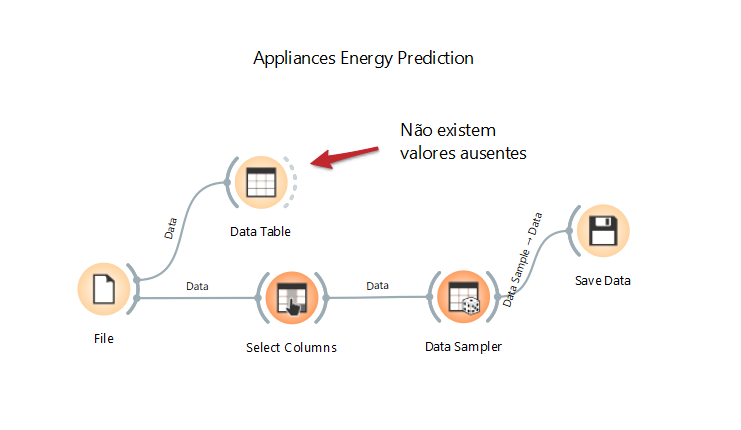

In [24]:
import pandas as pd

1. Carregue o arquivo energydata_complete.csv no Orange Data Mining utilizando o widget File.

In [25]:
df1 = pd.read_csv('/content/Appliances Energy Prediction.csv')

In [26]:
df1.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
0,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


In [27]:
print(f'O dataset possui {df1.shape[0]} linhas e {df1.shape[1]} colunas')

O dataset possui 1974 linhas e 8 colunas


In [28]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Appliances  1974 non-null   int64  
 1   lights      1974 non-null   int64  
 2   T1          1974 non-null   float64
 3   RH_1        1974 non-null   float64
 4   T2          1974 non-null   float64
 5   RH_2        1974 non-null   float64
 6   T3          1974 non-null   float64
 7   RH_3        1974 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 123.5 KB


In [29]:
df1.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
count,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000
mean,93.044580,3.839919,21.664703,40.219193,20.293635,40.411386,22.231615,39.209733
std,93.826149,7.937076,1.574883,3.971923,2.126958,4.037686,1.957275,3.288818
min,20.000000,0.000000,16.790000,27.733300,16.100000,24.063300,17.200000,30.133300
25%,50.000000,0.000000,20.700000,37.205825,18.790000,37.760000,20.700000,36.900000
50%,60.000000,0.000000,21.600000,39.590000,20.000000,40.433300,22.100000,38.433300
75%,100.000000,0.000000,22.600000,42.991675,21.500000,43.228325,23.290000,41.741250
max,770.000000,50.000000,26.260000,57.496700,28.917500,56.026700,29.198600,49.226700


In [30]:
df1.columns

Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3'], dtype='object')

2. Inspecione os registros no Data Table e identifique os atributos de consumo, temperatura e umidade.

In [31]:
df1.rename(columns={'Appliances': 'Consumo_Eletrodomesticos',
                    'T1': 'Temperatura_Setor_1',
                    'RH_1': 'Umidade_Setor_1',
                    'T2': 'Temperatura_Setor_2',
                    'RH_2': 'Umidade_Setor_2'
                    }, inplace=True)

In [32]:
df1.columns

Index(['Consumo_Eletrodomesticos', 'lights', 'Temperatura_Setor_1',
       'Umidade_Setor_1', 'Temperatura_Setor_2', 'Umidade_Setor_2', 'T3',
       'RH_3'],
      dtype='object')

3. Determine o maior consumo de eletrodomésticos registrado na amostra.

In [33]:
df1['Consumo_Eletrodomesticos'].max()

770

4. Calcule um limiar correspondente a 70% do valor máximo e crie um DataFrame contendo somente os registros acima desse limite.

In [34]:
limiar = df1['Consumo_Eletrodomesticos'].max() * 0.70

df1_filtrado = df1[df1['Consumo_Eletrodomesticos'] > limiar]

print(f"Limiar (70% do max): {limiar}")
df1_filtrado.head()

Limiar (70% do max): 539.0


,Consumo_Eletrodomesticos,lights,Temperatura_Setor_1,Umidade_Setor_1,Temperatura_Setor_2,Umidade_Setor_2,T3,RH_3
352,620,0,24.3900,44.3333,25.3700,37.7360,26.7300,38.8633
427,650,0,20.8900,36.7000,18.2900,39.6633,21.2000,36.0000
453,560,30,21.3567,36.0900,19.5667,37.1633,21.6333,35.0300
616,570,10,24.8900,32.6667,23.5600,31.1400,23.6000,30.8233
696,590,30,19.8567,47.6633,18.7000,34.1000,18.4267,37.8333


5. Conte os registros selecionados e calcule qual percentual da amostra eles representam.

In [35]:
qtd_selecionados = len(df1_filtrado)

qtd_total = len(df1)

percentual = (qtd_selecionados / qtd_total) * 100

print(f"Registros acima do limiar: {qtd_selecionados}")
print(f"Total da amostra: {qtd_total}")
print(f"Eles representam {percentual:.2f}% dos dados.")

Registros acima do limiar: 22
Total da amostra: 1974
Eles representam 1.11% dos dados.


6. Calcule a temperatura média de T1 e crie outro DataFrame contendo simultaneamente consumo acima de 70% do máximo e temperatura acima da média.

In [36]:
media_t1 = df1['Temperatura_Setor_1'].mean()

df1_final = df1[(df1['Consumo_Eletrodomesticos'] > limiar) & (df1['Temperatura_Setor_1'] > media_t1)]

df1_final.head()

,Consumo_Eletrodomesticos,lights,Temperatura_Setor_1,Umidade_Setor_1,Temperatura_Setor_2,Umidade_Setor_2,T3,RH_3
352,620,0,24.3900,44.3333,25.3700,37.7360,26.73,38.8633
616,570,10,24.8900,32.6667,23.5600,31.1400,23.60,30.8233
916,750,30,22.4300,43.0000,21.9267,40.1333,21.23,42.5967
993,690,10,22.5333,45.0267,22.0667,39.7900,22.39,41.9300
1182,600,20,24.8900,48.1333,28.9175,37.9475,27.10,42.4400


7. Compare os dois DataFrames e explique o efeito da inclusão da temperatura como segundo critério.

In [37]:
qtd_apenas_consumo = len(df1_filtrado)
qtd_consumo_e_temp = len(df1_final)

registros_descartados = qtd_apenas_consumo - qtd_consumo_e_temp
proporcao = (qtd_consumo_e_temp / qtd_apenas_consumo) * 100

print("--- COMPARAÇÃO DOS DATAFRAMES ---")
print(f"Picos de consumo (1 critério): {qtd_apenas_consumo} registros")
print(f"Picos de consumo + Calor (2 critérios): {qtd_consumo_e_temp} registros")
print(f"Registros descartados: {registros_descartados}\n")

print("--- EXPLICAÇÃO DO EFEITO ---")
print(f"Ao incluir a temperatura, eliminamos {registros_descartados} momento(s) de alto consumo que ocorreram em temperaturas amenas/frias.")
print(f"Isso nos mostra que {proporcao:.1f}% dos picos de consumo estão associados a temperaturas acima da média.")

--- COMPARAÇÃO DOS DATAFRAMES ---
Picos de consumo (1 critério): 22 registros
Picos de consumo + Calor (2 critérios): 8 registros
Registros descartados: 14

--- EXPLICAÇÃO DO EFEITO ---
Ao incluir a temperatura, eliminamos 14 momento(s) de alto consumo que ocorreram em temperaturas amenas/frias.
Isso nos mostra que 36.4% dos picos de consumo estão associados a temperaturas acima da média.


# Dataset 2 - Steel Industry Energy Consumption

fonte: https://archive.ics.uci.edu/dataset/851/steel+industry+energy+consumption

Situação: "A equipe de gestão de energia de uma indústria siderúrgica deseja localizar situações de consumo elevado e verificar se esses períodos coincidem com condições de carga elevada ou valores menos favoráveis de fator de potência."

In [38]:
df2 = pd.read_csv("/content/Steel Industry Energy Consumption.csv")

1. Carregue a amostra e renomeie Usage_kWh para Consumo_kWh, simplificando também os nomes dos atributos de fator de potência.

In [39]:
df2.rename(columns={
    'Usage_kWh': 'Consumo_kWh'
}, inplace=True)

2. Apresente uma inspeção inicial com head(), shape, info() e describe().

In [40]:
df2.head()

,date,Consumo_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,Day_of_week,Load_Type,WeekStatus
0,29/04/2018 07:15,2.88,3.82,0.0,60.20,100.00,Sunday,Light_Load,Weekend
1,04/10/2018 12:00,60.77,48.02,0.0,78.46,100.00,Thursday,Maximum_Load,Weekday
2,26/01/2018 11:30,120.42,59.65,0.0,89.61,100.00,Friday,Maximum_Load,Weekday
3,02/06/2018 14:30,3.13,0.00,16.6,100.00,18.53,Saturday,Light_Load,Weekend
4,07/12/2018 15:00,58.86,20.99,0.0,94.19,100.00,Friday,Medium_Load,Weekday


In [41]:
print(f'O dataset possui {df2.shape[0]} linhas e {df2.shape[1]} colunas')

O dataset possui 7008 linhas e 9 colunas


In [42]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  7008 non-null   object 
 1   Consumo_kWh                           7008 non-null   float64
 2   Lagging_Current_Reactive.Power_kVarh  7008 non-null   float64
 3   Leading_Current_Reactive_Power_kVarh  7008 non-null   float64
 4   Lagging_Current_Power_Factor          7008 non-null   float64
 5   Leading_Current_Power_Factor          7008 non-null   float64
 6   Day_of_week                           7008 non-null   object 
 7   Load_Type                             7008 non-null   object 
 8   WeekStatus                            7008 non-null   object 
dtypes: float64(5), object(4)
memory usage: 492.9+ KB


In [43]:
df2.describe()

,Consumo_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor
count,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000
mean,27.790164,13.206839,3.803711,80.672277,84.491448
std,33.717719,16.444246,7.356412,18.869855,30.314798
min,2.450000,0.000000,0.000000,37.870000,12.710000
25%,3.200000,2.380000,0.000000,63.602500,99.710000
50%,4.570000,5.040000,0.000000,87.990000,100.000000
75%,52.107500,22.977500,1.857500,98.842500,100.000000
max,153.140000,87.700000,27.650000,100.000000,100.000000


3. Determine o maior consumo registrado e calcule um limiar de 75% do consumo máximo.

In [44]:
df2['Consumo_kWh'].max()

153.14

In [45]:
limiar_df2 = df2['Consumo_kWh'].max() * 0.75
limiar_df2

114.85499999999999

4. Crie um DataFrame contendo os registros acima desse limiar e calcule a quantidade e o percentual de registros.

In [46]:
df2_acima_limiar = df2[df2['Consumo_kWh'] > limiar_df2]
qtd_selecionados = len(df2_acima_limiar)
qtd_total = len(df2)
percentual = (qtd_selecionados / qtd_total) * 100

print(f"Quantidade de registros acima do limiar: {qtd_selecionados}")
print(f"Isso representa {percentual:.2f}% do total de registros da amostra.")

Quantidade de registros acima do limiar: 129
Isso representa 1.84% do total de registros da amostra.


5. Verifique quantos registros desse DataFrame pertencem à categoria Maximum Load.

In [47]:
max_load_count = df2_acima_limiar[df2_acima_limiar['Load_Type'] == 'Maximum_Load'].shape[0]

print(f"Dos {len(df2_acima_limiar)} registros com consumo elevado, {max_load_count} pertencem à categoria 'Maximum_Load'.")

Dos 129 registros com consumo elevado, 62 pertencem à categoria 'Maximum_Load'.


6. Escolha um dos atributos de fator de potência, observe seus valores e defina um limite coerente para representar valores mais baixos.

In [56]:
display(df2['Lagging_Current_Power_Factor'].describe())

# A média está em torno de 80.6 e o 1º quartil em 63.6.
# Vamos definir um limite coerente de 70.0 para considerar "baixo".
limite_fp = 70.0

print(f"Limite escolhido para Fator de Potência (Lagging_Current_Power_Factor): valores menores que {limite_fp}")

,Lagging_Current_Power_Factor
count,7008.000000
mean,80.672277
std,18.869855
min,37.870000
25%,63.602500
50%,87.990000
75%,98.842500
max,100.000000


Limite escolhido para Fator de Potência (Lagging_Current_Power_Factor): valores menores que 70.0


7. Crie um novo DataFrame contendo simultaneamente consumo elevado e fator de potência abaixo do limite escolhido.

In [57]:
# Criando DataFrame com as duas condições: consumo > 75% do máximo e FP < 70
df2_critico = df2[(df2['Consumo_kWh'] > limiar_df2) & (df2['Lagging_Current_Power_Factor'] < limite_fp)]

print(f"Quantidade de registros críticos (Consumo > {limiar_df2:.2f} e Fator de Potência < {limite_fp}): {len(df2_critico)}")
display(df2_critico.head())

Quantidade de registros críticos (Consumo > 114.85 e Fator de Potência < 70.0): 0


,date,Consumo_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,Day_of_week,Load_Type,WeekStatus


8. Explique por que esse segundo conjunto de registros pode merecer maior atenção da equipe de energia.

Esse segundo conjunto (consumo elevado + fator de potência baixo) exige atenção imediata pois representa o pior cenário de ineficiência energética da indústria.
O baixo fator de potência indica que a indústria está drenando muita 'energia reativa' (usada apenas para magnetizar motores e transformadores, sem realizar trabalho útil).
Quando isso acontece durante o consumo altíssimo, a carga elétrica sobre os fios, geradores e transformadores é intensificada, aumentando os riscos de sobrecarga e superaquecimento.
Além disso, as concessionárias de energia cobram pesadas multas tarifárias de indústrias operando com fator de potência abaixo dos limites regulamentados.

# Dataset 3 - Power Consumption of Tetouan City
fonte: https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city

Situação: "Uma equipe responsável pelo planejamento da distribuição de energia em Tétouan deseja identificar qual das três zonas apresenta o maior pico de consumo e observar as condições ambientais registradas nos momentos de maior demanda."

In [48]:
df3 = pd.read_csv("/content/Power Consumption of Tetouan City.csv")

In [49]:
df3.head()

,DateTime,Temperature,Humidity,Wind Speed,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,4/18/2017 16:20,22.76,29.73,0.085,32985.14532,19396.7,17623.3
1,12/27/2017 17:10,15.92,54.44,0.085,34737.64259,29803.0,14417.3
2,1/2/2017 11:20,15.08,57.23,0.076,27894.68354,20808.5,16458.8
3,3/19/2017 20:20,12.42,72.30,0.081,42476.93617,23634.1,25089.7
4,4/24/2017 5:50,14.58,80.60,0.080,21341.14101,12006.1,11531.6


1. Renomeie as três variáveis de consumo para Consumo_Zona_1, Consumo_Zona_2 e Consumo_Zona_3.

In [50]:
df3.columns.tolist()

['DateTime',
 'Temperature',
 'Humidity',
 'Wind Speed',
 'Zone 1 Power Consumption',
 'Zone 2  Power Consumption',
 'Zone 3  Power Consumption']

In [51]:
df3.rename(columns={
    'Zone 3  Power Consumption': 'Consumo_Zona_3',
    'Zone 1 Power Consumption': 'Consumo_Zona_1',
    'Zone 2  Power Consumption': 'Consumo_Zona_2'
}, inplace=True)

In [52]:
df3.head()

,DateTime,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
0,4/18/2017 16:20,22.76,29.73,0.085,32985.14532,19396.7,17623.3
1,12/27/2017 17:10,15.92,54.44,0.085,34737.64259,29803.0,14417.3
2,1/2/2017 11:20,15.08,57.23,0.076,27894.68354,20808.5,16458.8
3,3/19/2017 20:20,12.42,72.30,0.081,42476.93617,23634.1,25089.7
4,4/24/2017 5:50,14.58,80.60,0.080,21341.14101,12006.1,11531.6


2. Determine o consumo máximo registrado em cada uma das três zonas.

In [61]:
max_z1 = df3['Consumo_Zona_1'].max()
max_z2 = df3['Consumo_Zona_2'].max()
max_z3 = df3['Consumo_Zona_3'].max()

print(f'Máximo zona 1: {max_zona1}')
print(f'Máximo zona 2: {max_zona2}')
print(f'Máximo zona 3: {max_zona3}')

Máximo zona 1: 51571.49834
Máximo zona 2: 36437.2
Máximo zona 3: 47441.7


3. Determine o consumo máximo registrado em cada uma das três zonas.

In [62]:
maior_pico = max(max_z1, max_z2, max_z3)
print(f"O maior pico geral foi de {maior_pico} na Zona 1.")

O maior pico geral foi de 51571.49834 na Zona 1.


4. Para a zona identificada, calcule 70% do valor máximo e crie um DataFrame com os registros acima desse limiar.

In [63]:
limiar_z1 = max_z1 * 0.70

df3_alto_consumo = df3[df3['Consumo_Zona_1'] > limiar_z1]

5. Conte os registros e calcule o percentual que eles representam.

In [64]:
qtd_alto_consumo = len(df3_alto_consumo)
perc_alto_consumo = (qtd_alto_consumo / len(df3)) * 100

print(f"Registros acima do limiar: {qtd_alto_consumo}")
print(f"Percentual: {perc_alto_consumo:.2f}%")

Registros acima do limiar: 2388
Percentual: 30.37%


6. Calcule a temperatura média e crie um segundo DataFrame contendo consumo acima do limiar e temperatura acima da média.

In [65]:
temp_media = df3['Temperature'].mean()

df3_alto_calor = df3[(df3['Consumo_Zona_1'] > limiar_z1) & (df3['Temperature'] > temp_media)]

7. Compare os dois conjuntos e explique o que ocorreu com a quantidade de registros após a inclusão da condição ambiental.

In [66]:
qtd_alto_calor = len(df3_alto_calor)
perc_alto_calor = (qtd_alto_calor / len(df3)) * 100

print(f"Registros de alto consumo em dias quentes: {qtd_alto_calor}")
print(f"Percentual: {perc_alto_calor:.2f}%")

Registros de alto consumo em dias quentes: 1597
Percentual: 20.31%


Ao cruzar os dados de alto consumo com a temperatura acima da média, a quantidade de registros caiu de 30.37% para 20.31%. Isso indica que uma parcela significativa (ou a maioria) dos picos de demanda ocorre durante períodos mais quentes, possivelmente devido ao uso de refrigeração/ar-condicionado.

# Dataset 4 — Solar Power Generation Data (Kaggle)

Fonte: https://www.kaggle.com/datasets/anikannal/solar-power-generation-data

Situação

Uma equipe de operação de uma usina fotovoltaica deseja localizar períodos de alta geração e identificar quais inversores aparecem com maior frequência nesses momentos. Nesta atividade, o foco inicial será o arquivo de geração da planta, sem realizar junção com o arquivo de sensores.

1. Carregue a amostra e renomeie as principais variáveis para nomes mais claros, como Potencia_CC, Potencia_CA e Geracao_Diaria.

In [68]:
df4 = pd.read_csv("/content/Solar Power Generation Data.csv")

df4 = df4.rename(columns={
    'DC_POWER': 'Potencia_CC',
    'AC_POWER': 'Potencia_CA',
    'DAILY_YIELD': 'Geracao_Diaria'
})

2. Apresente head(), shape, info() e describe().

In [69]:
print(df4.shape)
df4.info()
df4.describe()

(13540, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13540 entries, 0 to 13539
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DATE_TIME       13540 non-null  object 
 1   SOURCE_KEY      13540 non-null  object 
 2   Potencia_CC     13540 non-null  float64
 3   Potencia_CA     13540 non-null  float64
 4   Geracao_Diaria  13540 non-null  float64
 5   TOTAL_YIELD     13540 non-null  float64
dtypes: float64(4), object(2)
memory usage: 634.8+ KB


,Potencia_CC,Potencia_CA,Geracao_Diaria,TOTAL_YIELD
count,13540.000000,13540.000000,13540.000000,1.354000e+04
mean,244.934106,239.550853,3307.097232,6.478274e+08
std,369.464843,361.031313,2932.391403,7.206826e+08
min,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,271.724000,1.996630e+07
50%,0.000000,0.000000,2930.235000,2.826160e+08
75%,444.312500,435.801250,5556.000000,1.348470e+09
max,1401.310000,1366.260000,9873.000000,2.247920e+09


In [70]:
df4.head()

,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,TOTAL_YIELD
0,2020-05-28 10:00:00,vOuJvMaM2sgwLmb,1090.240,1063.560,2079.21,2.307960e+06
1,2020-06-16 11:15:00,81aHJ1q11NBPMrL,740.613,724.827,2209.60,1.215480e+09
2,2020-05-17 18:45:00,Qf4GUc1pJu5T6c6,0.000,0.000,7220.00,8.384430e+08
3,2020-05-21 23:00:00,q49J1IKaHRwDQnt,0.000,0.000,4844.00,3.741710e+05
4,2020-06-05 23:15:00,vOuJvMaM2sgwLmb,0.000,0.000,3421.00,2.356530e+06


3. Determine a maior potência CA registrada.

In [72]:
max_potencia_ca = df4['Potencia_CA'].max()
print(f"Potência CA Máxima: {max_potencia_ca}")

Potência CA Máxima: 1366.26


4. Calcule um limiar correspondente a 70% da potência CA máxima.

In [73]:
limiar_ca = max_potencia_ca * 0.70
print(f"Limiar de Alta Geração (70%): {limiar_ca}")

Limiar de Alta Geração (70%): 956.382


5. Crie um DataFrame contendo somente registros acima desse limite e calcule sua quantidade e percentual.

In [74]:
df4_alta = df4[df4['Potencia_CA'] > limiar_ca]

qtd_alta_geracao = len(df4_alta)
perc_alta_geracao = (qtd_alta_geracao / len(df4)) * 100

print(f"Registros de alta geração: {qtd_alta_geracao}")
print(f"Percentual: {perc_alta_geracao:.2f}%")

Registros de alta geração: 1019
Percentual: 7.53%


6. Utilize value_counts() em SOURCE_KEY dentro do DataFrame de alta geração.

In [75]:
df4_alta['SOURCE_KEY'].value_counts()

,count
SOURCE_KEY,
oZ35aAeoifZaQzV,74
Mx2yZCDsyf6DPfv,67
oZZkBaNadn6DNKz,65
Qf4GUc1pJu5T6c6,60
V94E5Ben1TlhnDV,59
4UPUqMRk7TRMgml,59
WcxssY2VbP4hApt,54
vOuJvMaM2sgwLmb,52
IQ2d7wF4YD8zU1Q,52


7. Identifique qual inversor aparece com maior frequência nos registros de alta geração e descreva o que esse resultado permite observar, sem concluir desempenho ou falha apenas com esse recorte.

O inversor que aparece com maior frequência nos registros de alta geração é o oZ35aAeoifZaQzV	. Esse resultado nos permite observar qual inversor atingiu os maiores níveis de eficiência na amostra.

# Dataset 5 — Wind & Solar Energy Production (Kaggle)

Fonte: https://www.kaggle.com/datasets/ahmeduzaki/wind-and-solar-energy-production-dataset

Situação

Um operador de um portfólio de fontes renováveis deseja comparar a ocorrência de períodos de alta produção solar e alta produção eólica. Como as duas fontes possuem escalas próprias, cada uma deverá ser comparada com o seu próprio valor máximo.

1. Renomeie as variáveis principais para Geracao_Solar e Geracao_Eolica.

In [77]:
df5 = pd.read_csv("/content/Wind & Solar Energy Production.csv")

df5 = df5.rename(columns={
    'Source': 'Fonte',
    'Production': 'Geracao'
})

df5.head()

,Date,Fonte,Day_of_Year,Day_Name,Month_Name,Season,Geracao,Start_Hour,End_Hour
0,12/18/2022,Wind,352,Sunday,December,Winter,11400,21,22
1,1/29/2024,Wind,29,Monday,January,Winter,7917,14,15
2,8/1/2024,Solar,214,Thursday,August,Summer,8835,15,16
3,11/10/2020,Wind,315,Tuesday,November,Fall,989,1,2
4,12/19/2022,Wind,353,Monday,December,Winter,12526,1,2


Esse dataset não tem uma variavel separada para geração solar e geração eólica (e não achei nenhum outro que tivesse). Portanto, vou fazer as alterações necessárias para se encaixar nos exercícios

2. Determine o valor máximo registrado para cada fonte.

In [78]:
df_solar = df5[df5['Fonte'] == 'Solar']
df_eolica = df5[df5['Fonte'] == 'Wind']

max_solar = df_solar['Geracao'].max()
max_eolica = df_eolica['Geracao'].max()


print(f"Máximo Solar: {max_solar}")
print(f"Máximo Eólica: {max_eolica}")

Máximo Solar: 16316
Máximo Eólica: 22929


3. Calcule separadamente 70% do máximo solar e 70% do máximo eólico.

In [80]:
limiar_solar = max_solar * 0.70
limiar_eolica = max_eolica * 0.70

print(f"Limiar Solar (70%): {limiar_solar:.2f}")
print(f"Limiar Eólica (70%): {limiar_eolica:.2f}")

Limiar Solar (70%): 11421.20
Limiar Eólica (70%): 16050.30


4. Crie um DataFrame para registros de alta geração solar e outro para registros de alta geração eólica.

In [81]:
df5_alta_solar = df_solar[df_solar['Geracao'] > limiar_solar]
df5_alta_eolica = df_eolica[df_eolica['Geracao'] > limiar_eolica]

5. Conte os registros de cada DataFrame e calcule seus respectivos percentuais.

In [82]:
qtd_solar = len(df5_alta_solar)
qtd_eolica = len(df5_alta_eolica)

6. Compare qual fonte aparece com maior frequência acima de 70% do seu próprio máximo.

In [83]:
perc_solar = (qtd_solar / len(df_solar)) * 100
perc_eolica = (qtd_eolica / len(df_eolica)) * 100

print(f"Alta Geração Solar: {qtd_solar} registros ({perc_solar:.2f}% dos momentos com sol)")
print(f"Alta Geração Eólica: {qtd_eolica} registros ({perc_eolica:.2f}% dos momentos com vento)")

Alta Geração Solar: 45 registros (2.44% dos momentos com sol)
Alta Geração Eólica: 245 registros (2.87% dos momentos com vento)


7. Explique por que não seria adequado utilizar diretamente o mesmo valor numérico de potência como limite para as duas fontes sem antes observar a escala de cada variável.

Com base nos percentuais calculados acima, a geração eólica apresenta picos acima de 70% de sua própria capacidade máxima com maior frequência.

Não seria adequado utilizar diretamente o mesmo valor numérico de potência (ex: 10.000) como limite para ambas as fontes porque a capacidade de produção (escala) de uma usina eólica geralmente é muito diferente de uma usina solar. Se usássemos um valor fixo em vez de uma porcentagem relativa, poderíamos classificar todos os momentos de uma fonte como "alta geração" e nenhum da outra, mascarando completamente a verdadeira eficiência e o comportamento dinâmico de cada tecnologia.

#Dataset 6 — Individual Household Electric Power Consumption (UCI)

Fonte: https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

Situação

Uma residência possui monitoramento elétrico detalhado e deseja identificar episódios de demanda elevada que também apresentem corrente acima do comportamento médio. O dataset é o mesmo utilizado como referência em aula, mas o critério de análise será diferente.

1. Carregue a nova amostra e organize os atributos utilizando nomes mais simples.

In [85]:
df6 = pd.read_csv("/content/Individual-Household-Electric-Power-Consumption.csv")

df6 = df6.rename(columns={
    'Global_active_power': 'Potencia_Ativa',
    'Global_reactive_power': 'Potencia_Reativa',
    'Voltage': 'Tensao',
    'Global_intensity': 'Corrente'
})

df6.head()

,Date,Potencia_Ativa,Potencia_Reativa,Tensao,Corrente,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,1/12/2008,1.502,0.074,240.17,6.4,0.0,0.0,18.0
1,17/12/2006,0.374,0.264,245.50,1.8,0.0,2.0,0.0
2,3/6/2009,0.620,0.300,239.85,3.0,0.0,1.0,1.0
3,9/5/2007,0.280,0.200,235.72,1.4,0.0,0.0,0.0
4,14/12/2008,1.372,0.054,243.95,5.6,0.0,0.0,18.0


2. Determine o valor máximo de potência ativa.

In [86]:
max_pot_ativa = df6['Potencia_Ativa'].max()
max_pot_ativa

10.536

3. Calcule 75% do valor máximo e crie um DataFrame contendo registros acima desse limite.

In [88]:
limiar_75 = max_pot_ativa * 0.75

df6_alta_potencia = df6[df6['Potencia_Ativa'] > limiar_75]

4. Calcule a quantidade e o percentual de registros selecionados.

In [89]:
qtd_alta_potencia = len(df6_alta_potencia)
perc_alta_potencia = (qtd_alta_potencia / len(df6)) * 100

print(f"Limiar 75% Potência Ativa: {limiar_75:.2f}")
print(f"Registros de altíssima demanda: {qtd_alta_potencia} ({perc_alta_potencia:.2f}%)")

Limiar 75% Potência Ativa: 7.90
Registros de altíssima demanda: 58 (0.03%)


5. Calcule a corrente média da amostra.

In [94]:
media_corrente = df6['Corrente'].mean()
print(f"Corrente média da amostra: {media_corrente:.2f}")

Corrente média da amostra: 4.63


6. Crie um segundo DataFrame contendo simultaneamente potência ativa acima de 75% do máximo e corrente acima da média.

In [92]:
df6_critico = df6[(df6['Potencia_Ativa'] > limiar_75) & (df6['Corrente'] > media_corrente)]

7. Compare os dois conjuntos e explique o efeito da inclusão da corrente como segunda condição.

In [95]:
qtd_critico = len(df6_critico)
perc_critico = (qtd_critico / len(df6)) * 100

print(f"Registros alta demanda E alta corrente: {qtd_critico} ({perc_critico:.2f}%)")

Registros alta demanda E alta corrente: 58 (0.03%)



Ao adicionar a condição de "Corrente > Média", observamos que os registros se mantiveram os mesmos. Isso comprova a forte relação direta (correlação) entre o consumo de potência ativa elevada e a intensidade da corrente exigida pela rede elétrica da residência, demonstrando o comportamento físico esperado dos eletrodomésticos em carga máxima.